<center>

![](recursos/img/logoitqv1.jpg)

</center>

## PAO26-26-Python 1, Regresion Logistica 2

<center>

![](recursos/img/python_logo.png)

</center>

*Cynthia Cuñez*

 Repositorio: <a href="https://github.com/cynthia0206/machine12926nocturno/blob/main/PAO26-07-22-REGRESION-LOGISTICA.ipynb">Link del repositorio de Github</a>

 * https://github.com/cynthia0206/machine12926nocturno/blob/main/PAO26-07-22-REGRESION-LOGISTICA.ipynb

# 2. Práctica Académica

## 2.1 Normalización y Estandarización de Datos en Inteligencia Artificial

# 3. Análisis y aplicación de técnicas de normalización y estandarización en conjuntos de datos para modelos de aprendizaje automático

### 3.0.1 Objetivo General

Aplicar técnicas de normalización y estandarización de datos mediante herramientas de Python, con el fin de comprender su impacto en la preparación de datos y en el desempeño de modelos de aprendizaje automático.

### Objetivos Específicos

- Identificar diferencias de escala entre variables numéricas.
- Aplicar técnicas de normalización (Min-Max).
- Aplicar técnicas de estandarización (Z-score).
- Analizar la importancia del preprocesamiento en modelos de Inteligencia Artificial.

### Antecedentes / Fundamentación Teórica

En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados poco confiables.

Para mitigar este problema, se emplean técnicas como:

- **Normalización:** transforma los datos a un rango específico, generalmente **[0,1]**.
- **Estandarización:** ajusta los datos para que tengan una media de **0** y una desviación estándar de **1**.

Estas técnicas son fundamentales en algoritmos como:

- K-Nearest Neighbors (KNN).
- Regresión Logística.
- Redes Neuronales.

### Escenario de Práctica

Una empresa de análisis de datos desea desarrollar modelos predictivos utilizando información de clientes. Sin embargo, se ha identificado que las variables presentan diferentes escalas, lo que puede afectar el rendimiento de los modelos.

Se solicita al analista aplicar técnicas de preprocesamiento y limpieza de datos para mejorar la calidad de los datos antes de entrenar los modelos de aprendizaje automático.

## Conjunto de Datos a Utilizar

**Dataset 1 (Conceptual):**
- Iris Dataset.

**Dataset 2 (Aplicación Real):**
- California Housing Dataset.

In [2]:
#Importacion de librerias
import pandas as pd
import numpy as np
#from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [7]:
import os

os.environ["KAGGLE_CONFIG_DIR"] = os.path.join(os.path.expanduser("~"), ".kaggle")

In [8]:
 #Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [9]:
#Descargamos el dataset
!kaggle datasets download -d uciml/iris

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0




  0%|          | 0.00/3.60k [00:00<?, ?B/s]
100%|##########| 3.60k/3.60k [00:00<00:00, 6.10MB/s]


In [10]:
import zipfile

with zipfile.ZipFile("iris.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [11]:
 #Cargamos el conjunto de datos
df = pd.read_csv("dataset/Iris.csv")

In [12]:
#mostramos el conjunto de datos"
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
#Eliminamos columnas innecesarias en la limpieza de datos como vemos en el dataframe la columna id no aporta
#nada a nuestro modelo por lo tanto lo eliminamos
if 'Id' in df.columns:
    df=df.drop(columns=["Id"])
    df.head()

In [15]:
#Mostramos los detalles de nuesto dataset
df.info()
#Vrificamos si tenemos datos nulos si lo tenemos lo sumamos
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [16]:
#Separamos los datos de entrada con nuestra variable objetivo
X=df.drop(columns=['Species'])
y=df['Species']


In [17]:
#Exploramos o generamos un analis exploratorio del conjutno de datos
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 3.0.2 Conclusión

Al observar la tabla del conjunto de datos, se aprecia que cada variable presenta valores con diferentes rangos y escalas. Por ejemplo:

- **PetalLengthCm** tiene valores que van aproximadamente desde **1.0** hasta **6.9**, lo que indica una amplia variación.
- En cambio, **SepalWidthCm** presenta valores entre **2.0** y **4.4**, mostrando una menor variabilidad.

Esto demuestra que las variables no se encuentran en la misma escala.

### ¿Qué significa?

Al analizar los datos, se observa que algunas variables poseen valores numéricos más grandes que otras. En algoritmos de aprendizaje automático, como **K-Nearest Neighbors (KNN)**, esto puede generar que:

- Las variables con valores más grandes tengan un mayor peso en el cálculo de las distancias.
- Influyan más en las decisiones del modelo.

Si no se realiza un preprocesamiento adecuado, el modelo puede dar mayor importancia a variables como **PetalLengthCm** y menor relevancia a otras características, generando un sesgo en los resultados.

Para evitar este problema se aplican técnicas de preprocesamiento como:

- **Normalización.**
- **Estandarización.**

Estas técnicas permiten que todas las variables se encuentren en una escala comparable, otorgándoles una importancia similar durante el entrenamiento del modelo y mejorando su desempeño y capacidad de generalización.

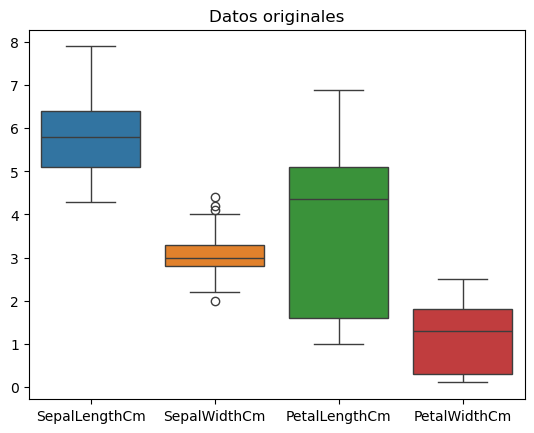

In [18]:
#dibujamso los datos originales
sns.boxplot(data=X)
#Ponemos un titulo a la imagen
plt.title("Datos originales")
plt.show()

### 3.1 Interpretación de la Imagen

El gráfico permite observar que las variables del conjunto de datos presentan diferentes escalas y niveles de variabilidad. Algunas características poseen rangos de valores más amplios que otras, lo que puede influir en el comportamiento de los modelos de aprendizaje automático.

Cuando las variables no se encuentran en la misma escala, aquellas con valores más altos pueden tener una mayor influencia en el entrenamiento del modelo, especialmente en algoritmos basados en distancias, como **K-Nearest Neighbors (KNN)**. Esto puede provocar resultados sesgados y reducir el rendimiento del modelo.

Por esta razón, es necesario aplicar técnicas de preprocesamiento como:

- **Normalización**, que transforma los datos a un rango específico, generalmente entre **0 y 1**.
- **Estandarización**, que ajusta los datos para que tengan una media de **0** y una desviación estándar de **1**.

La aplicación de estas técnicas permite equilibrar la influencia de todas las variables, mejorar la calidad de los datos y aumentar la precisión de los modelos de Inteligencia Artificial.

In [19]:
 #Normalizamos el conjunto de datos
normalizer = preprocessing.MinMaxScaler()
X_norm=normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [20]:
X_norm.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [21]:
#Estaddarización
standarizer = preprocessing.StandardScaler()
#Estandarizamos los datos
X_std=standarizer.fit_transform(X)
X_std= pd.DataFrame(X_std, columns=X.columns)
X_std.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


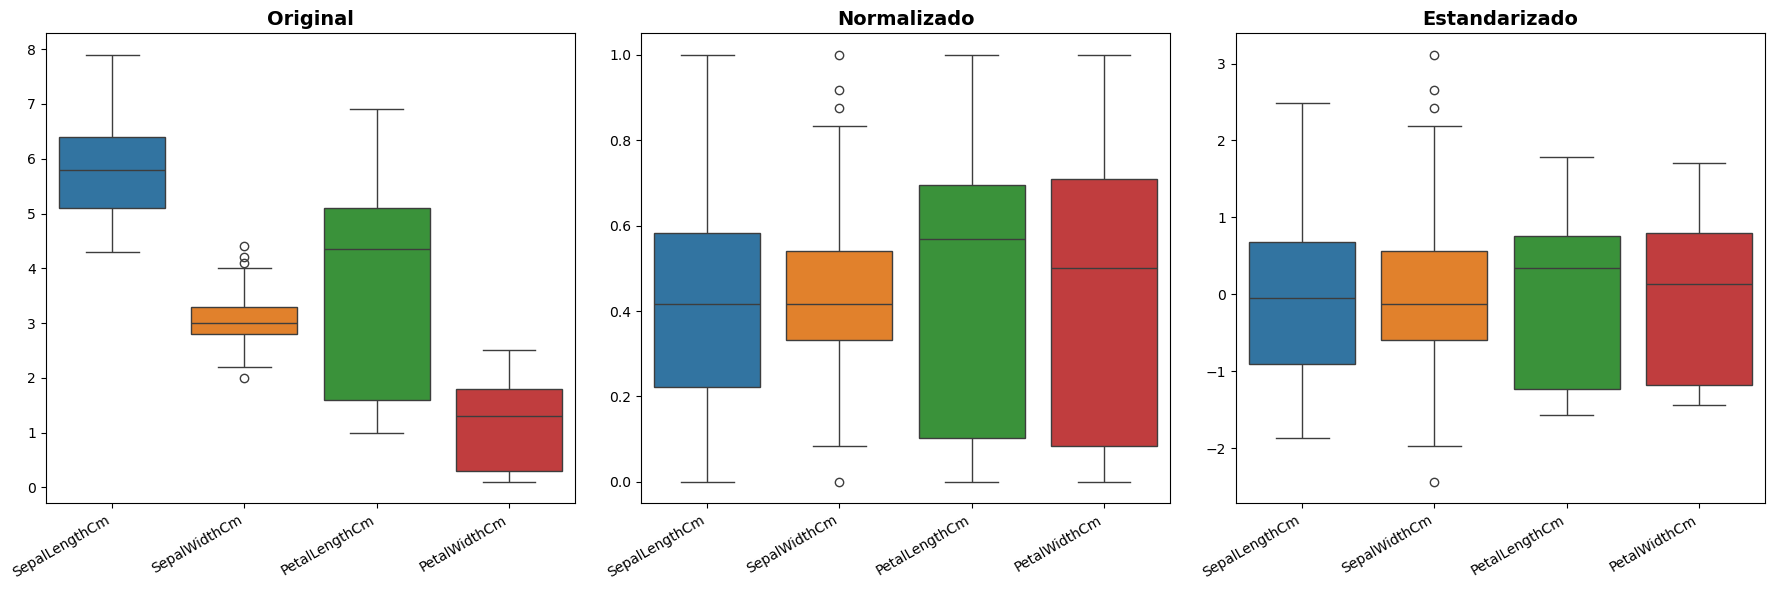

In [24]:
# Comparación visual
plt.figure(figsize=(18, 6))

# Datos originales
plt.subplot(1, 3, 1)
sns.boxplot(data=X)
plt.title("Original", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")

# Datos normalizados
plt.subplot(1, 3, 2)
sns.boxplot(data=X_norm)
plt.title("Normalizado", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")

# Datos estandarizados
plt.subplot(1, 3, 3)
sns.boxplot(data=X_std)
plt.title("Estandarizado", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")

# Ajustar automáticamente los espacios
plt.tight_layout()

plt.show()